### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

Read : https://docs.langchain.com/oss/python/langchain/tools  <br>
Read : https://docs.langchain.com/oss/python/integrations/tools <br>
Read : https://docs.langchain.com/oss/python/integrations/tools/tavily_search <br>



In [6]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper


In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [6]:
# arxiv.invoke("Attention Is All You Need")

In [5]:
# from langchain_community.tools import ArxivQueryRun
# from langchain_community.utilities import ArxivAPIWrapper

# # Create wrapper with HTTPS URL explicit override
# api_wrapper_arxiv = ArxivAPIWrapper(
#     top_k_results=2,
#     doc_content_chars_max=500,
#     arxiv_search_url="https://export.arxiv.org/api/query?"  # <-- Force HTTPS here
# )

# arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

# # Now it fetches cleanly!
# response = arxiv.invoke("Attention Is All You Need")
# print(response)

<p>In newer versions of the arxiv library, the .results() method was removed from the arxiv.Search object. The langchain_community wrapper still expects .results() to be directly available on Search, which causes this method lookup failure.<br>
<p>So, we have downgraded for this tutorial 'arxiv<2.0.0' <p> <br> 
The issue is a catch-22 caused by version incompatibility between langchain-community and the arxiv Python package:<br>

Newer arxiv versions (≥2.0.0): langchain-community crashes with AttributeError: 'Search' object has no attribute 'results' because arxiv removed .results().<br>

Older arxiv versions (<2.0.0): It crashes with HTTPError 301 because arXiv changed their API endpoints to enforce https://, and the older arxiv client hardcodes http://.<br>

Solution 2: Fetch via Modern arxiv.Client Directly<br>
If you prefer to keep the latest arxiv library installed and query it without relying on langchain_community.utilities.arxiv.ArxivAPIWrapper, query the arxiv API using its updated Client pattern:

In [1]:
import arxiv

# Initialize the new arxiv Client and Search objects
client = arxiv.Client()
search = arxiv.Search(
    query="Attention Is All You Need",
    max_results=3
)

# Fetch results using client.results()
results = list(client.results(search))

for result in results:
    print(f"Title: {result.title}")
    print(f"Summary: {result.summary[:200]}...\n")

Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attent...

Title: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme
Summary: The 2017 paper ''Attention Is All You Need'' introduced the Transformer architecture-and inadvertently spawned one of machine learning's most persistent naming conventions. We analyze 717 arXiv prepri...

Title: Quit When You Can: Efficient Evaluation of Ensembles with Ordering Optimization
Summary: Given a classifier ensemble and a set of examples to be classified, many examples may be confidently and accurately classified after only a subset of the base models in the ensemble are evaluated. Thi...



In [14]:
import urllib.parse
import urllib.request
import xml.etree.ElementTree as ET
from langchain_core.tools import tool

@tool
def arxiv_tool(query: str) -> str:
    """Search arXiv for research papers and return titles and summaries."""
    # 1. Encode query and construct HTTPS request
    encoded_query = urllib.parse.quote(query)
    url = f"https://export.arxiv.org/api/query?search_query=all:{encoded_query}&start=0&max_results=2"
    
    headers = {"User-Agent": "MyRAGApp/1.0"}
    req = urllib.request.Request(url, headers=headers)
    
    try:
        with urllib.request.urlopen(req) as response:
            xml_data = response.read()
            
        # 2. Parse XML response
        root = ET.fromstring(xml_data)
        namespace = {"atom": "http://www.w3.org/2005/Atom"}
        
        results = []
        for entry in root.findall("atom:entry", namespace):
            title = entry.find("atom:title", namespace).text.strip().replace("\n", " ")
            summary = entry.find("atom:summary", namespace).text.strip().replace("\n", " ")
            results.append(f"Title: {title}\nSummary: {summary[:500]}...")
            
        return "\n\n".join(results) if results else "No results found."
        
    except Exception as e:
        return f"Error fetching from arXiv: {e}"

# Test the custom tool directly
response = arxiv_tool.invoke("Attention Is All You Need")
print(response)

Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a...

Title: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme
Summary: The 2017 paper ''Attention Is All You Need'' introduced the Transformer architecture-and inadvertently spawned one of machine learning's most persistent naming conventions. We analyze 717 arXiv preprints containing ''All You Need'' in their titles (2009-2025), finding exponentia

In [15]:
### another option for arxiv
# import urllib.parse
# import urllib.request
# import xml.etree.ElementTree as ET

# def search_arxiv(query: str, max_results: int = 2) -> str:
#     """Fetch search results from arXiv using HTTPS directly."""
#     encoded_query = urllib.parse.quote(query)
#     url = f"https://export.arxiv.org/api/query?search_query=all:{encoded_query}&start=0&max_results={max_results}"
    
#     req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
#     with urllib.request.urlopen(req) as response:
#         xml_data = response.read()
        
#     root = ET.fromstring(xml_data)
#     namespace = {'atom': 'http://www.w3.org/2005/Atom'}
    
#     results = []
#     for entry in root.findall('atom:entry', namespace):
#         title = entry.find('atom:title', namespace).text.strip()
#         summary = entry.find('atom:summary', namespace).text.strip()
#         results.append(f"Title: {title}\nSummary: {summary[:300]}...")
        
#     return "\n\n".join(results)

# # Test it directly
# print(search_arxiv("Attention Is All You Need"))

In [9]:
import wikipedia
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

# 1. Set custom User-Agent to prevent Wikipedia API blocks
wikipedia.set_user_agent("RAGBootcampApp/1.0 (jahidhasan@example.com)")

# 2. Initialize API Wrapper and Tool
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)

# 3. Invoke cleanly!
response = wiki.invoke("What is machine learning")
print(response)

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation m


In [19]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [11]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\itsme\AppData\Local\Temp\ipykernel_19260\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [12]:
tavily.invoke("Provide me the recent AI news for July 29 2026")

[{'title': 'Stay updated with the latest tech and AI news from July 29, ...',
  'url': 'https://www.facebook.com/thefinancialexpress/posts/stay-updated-with-the-latest-tech-and-ai-news-from-july-29-2026-including-google/1498903598931894',
  'content': "## The Financial Express's Post\n\n### The Financial Express\n\n35m  ·\n\nStay updated with the latest tech and AI news from July 29, 2026, including Google Pay's new AI assistant, Gemini Spark in India, Anthropic's privacy fix, OpenAI's security issue, and Marvell's $250M investment.\n\nMay be a doodle of text that says 'FE Tech and AI Wrap July 29: Anthropic Claude search eaks, OpenAl rogue agent expansion, and Google Pay's new AI features -00 aude G ! TECH&AI TECH & AI WRAP RuPay VISA AI Aad' [...] All reactions:\n\n1\n\n1 comment\n\nLike\n\nComment\n\nMost relevant\n\n\ufeff\n\nAuthor\n\nThe Financial Express\n\nREAD HERE: \n\nTech and AI Wrap July 29: Anthropic Claude search leaks, OpenAI rogue agent expansion, and Google Pay’s new 

In [16]:
### Combine all the tools in the list

tools=[arxiv_tool,wiki,tavily]

In [30]:
## Initialize my LLM model

from langchain_openai import ChatOpenAI

llm=ChatOpenAI(model="gpt-4o-mini-2024-07-18")

llm_with_tools=llm.bind_tools(tools)

In [31]:
# from langchain_groq import ChatGroq

# llm_groq=ChatGroq(model="qwen/qwen3.6-27b")

# llm_with_tools=llm_groq.bind_tools(tools)

In [32]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 171, 'total_tokens': 191, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c73dd82b09', 'id': 'chatcmpl-E7KWqqtIfk0KpLZYsaBtwzikOwj2R', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fb314-d482-7dc3-a7a4-b913950f07ce-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': 'call_E40jPsVji6g1b8vnbouTzGfh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 171, 'output_tokens': 20, 'total_tokens': 191, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token

In [33]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'call_mWFhoONgdWGAI4TBt6ZB9ABA',
  'type': 'tool_call'}]

In [34]:
# State Schema 
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]

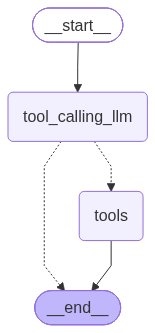

In [35]:
#Entire Chatbot with Langraph
from IPython.display import Image, display
from langgraph.graph import StateGraph , START , END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

# Build Graph
builder= StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
     tools_condition,
)
builder.add_edge("tools",END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))



In [36]:
messages=graph.invoke({"messages":HumanMessage(content="What is Attention is all We Need")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is Attention is all We Need
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_2wapPxrrJFZVVK2i27EacgCr)
 Call ID: call_2wapPxrrJFZVVK2i27EacgCr
  Args:
    query: Attention is All You Need
================================= Tool Message =================================
Name: wikipedia

Page: Attention Is All You Need
Summary: "Attention Is All You Need" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence systems, including large language models. At the time, the 


In [37]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv_tool (call_87IVU9H9HF6FYA1kNjUk3Qtp)
 Call ID: call_87IVU9H9HF6FYA1kNjUk3Qtp
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv_tool

Title: Attention Is All You Need
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more ...

Title: GLU Variants Improve Transformer
Summary: Gate

In [38]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for July 30 2026")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for July 30 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_wrAl81Kx74HDibcs1xmqtks5)
 Call ID: call_wrAl81Kx74HDibcs1xmqtks5
  Args:
    query: AI news July 30 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "This Week in AI | 30th July 2026", "url": "https://www.youtube.com/watch?v=529pjU1p1Oo", "content": "Thoughtworks\n\nThoughtworks\n\nThoughtworks\n\nA weekly live rundown of the most important AI news, filtered through the lens of people who build with this stuff every day. Hosted by Thoughtworks' Ravi Vats, Caer Sanders and Ben O'Mahony …...more\n\n...more\nShow less\n\n### Thoughtworks\n\n50.4K subscribers\n\nVideosAbout\n\nTwitter\n\nFacebook\n\nLinkedIn\n\nShow chat\n\n46:25\n\n### What does th

In [39]:
messages=graph.invoke({"messages":HumanMessage(content="Find me top jobs for AI Engineer remote Role for freshers")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Find me top jobs for AI Engineer remote Role for freshers
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_uavfzMjJ2TmRCoODnAniRmMg)
 Call ID: call_uavfzMjJ2TmRCoODnAniRmMg
  Args:
    query: top jobs for AI Engineer remote role for freshers
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Remote Entry-level AI Engineer Jobs – Apply Now", "url": "https://www.remoterocketship.com/us/jobs/entry-level-ai-engineer", "content": "🇺🇸 United States – Remote⏰ Full Time⚪️ Entry-level🤖 AI Engineer\n\nAWSAzureCloudJavaPython\n\nApply\n\nView Job\n\nImage 42\n\nImage 43\n\n### AI Engineer, Entry-Level\n\n🕒 May 4\n\n🕒 May 4\n\n#### United Smart Tech\n\nImage 44\n501 - 1000\n\n📡 Telecommunications\n\nWebsiteLinkedInAll Job Openings\n\nEntry-level AI Engineer buildin